# 데이터 타입 변환 & 결측치 처리 기초

In [1]:
import pandas as pd

# 예시 데이터프레임 생성
data = pd.DataFrame({
    'A':['1', '2', '3'],
    'B':['4', '5', '6'],
    'C':['7', '8', '9']
})
data

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      str  
 1   B       3 non-null      str  
 2   C       3 non-null      str  
dtypes: str(3)
memory usage: 204.0 bytes


## apply(pd.to_numeric)
- 선택한 여러 열에 한 번에 숫자 변환 함수를 적용

In [4]:
# 데이터 타입을 int로 변경
data[['A', 'B', 'C']] = data[['A', 'B', 'C']].apply(pd.to_numeric)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      int64
 1   B       3 non-null      int64
 2   C       3 non-null      int64
dtypes: int64(3)
memory usage: 204.0 bytes


In [6]:
pd.__version__

'3.0.3'

## dropna()
- 결측값이 있는 행 제거
- 가장 간단하지만 데이터가 많이 삭제될 수 있어 신중하게 사용해야 한다
- 결측치 비율이 매우 낮을 때만 권장한다
- 기본값은 행 기준(axis=0)
- axis=1 : 열 기준

In [7]:
data = pd.DataFrame({
    'A':['1', '2', '3', None],
    'B':['4', None, '5', '6'],
    'C':[None, '7', '8', '9']
})
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [8]:
data.dropna()

,A,B,C
2,3,5,8


In [9]:
data_dropna = data.dropna()
data_dropna

,A,B,C
2,3,5,8


In [10]:
data_dropna_col = data.dropna(axis=1)
data_dropna_col

""
0
1
2
3


## fillna()
- 결측치를 다른 값으로 채운다

## 결측값을 0으로 채우기
- 행이 삭제되지 않아 데이터 손실은 없지만, 0이라는 값의 실제 의미가 작용할 때는 혼동될 수 있다

In [11]:
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [12]:
data.fillna(0)

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


In [13]:
data_fillna0 = data.fillna(0)
data_fillna0

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


## 결측값을 평균으로 채우기 - fillna(mean())
- mean() : 평균
- 숫자형 데이터(나이, 온도, 점수 등)에서 가장 널리 쓰이는 결측치 처리 방식
- 극단적인 이상치가 있으면 평균이 왜곡될 수 있으니, 이상치 제거 후 평균을 채우는 순서가 안전하다

In [19]:
data_numeric = data.apply(pd.to_numeric)
data_numeric

,A,B,C
0,1.0,4.0,NaN
1,2.0,NaN,7.0
2,3.0,5.0,8.0
3,NaN,6.0,9.0


In [20]:
data_numeric.fillna(data_numeric.mean())

,A,B,C
0,1.0,4.0,8.0
1,2.0,5.0,7.0
2,3.0,5.0,8.0
3,2.0,6.0,9.0


In [21]:
avg = data_numeric.mean()
data_numeric.fillna(avg)

,A,B,C
0,1.0,4.0,8.0
1,2.0,5.0,7.0
2,3.0,5.0,8.0
3,2.0,6.0,9.0


In [22]:
data_numeric = data_numeric.fillna(avg)
data_numeric

,A,B,C
0,1.0,4.0,8.0
1,2.0,5.0,7.0
2,3.0,5.0,8.0
3,2.0,6.0,9.0


## 결측값을 최빈값으로 채우기

## 최빈값 : mode()
- 해당 열에서 가장 자주 나온 값들을 리스트 형태로 변환
- 최빈값이 여러 개여도 첫 번째 값 불러오기 → [0]

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      str  
 1   B       3 non-null      str  
 2   C       3 non-null      str  
dtypes: str(3)
memory usage: 228.0 bytes


In [24]:
mode_a = data['A'].mode()

mode_a

0    1
1    2
2    3
Name: A, dtype: str

In [25]:
type(mode_a)

pandas.Series

In [26]:
mode_a[0]

'1'

In [29]:
mode_b = data['B'].mode()[0]
mode_b

'4'

In [30]:
mode_c = data['C'].mode()[0]
mode_c

'7'

In [32]:
data['A'].fillna(mode_a[0])

0    1
1    2
2    3
3    1
Name: A, dtype: str

In [ ]:
# 데이터프레임의 열마다 같은 코드를 반복 적용시킬 때
data.apply(lambda x: x.fillna(x.mode()[0]))

,A,B,C
0,1,4,7
1,2,4,7
2,3,5,8
3,1,6,9


## 열마다 다른 값으로 결측치 대체 (딕셔너리 활용)
- 열마다 성격이 다를 때 사용
- 성별은 최빈값, 지역은 '기타'

In [35]:
data2 = pd.DataFrame({
    '성별':['남', '남', '여', '남', None, '여'],
    '지역':['대구', '서울', '서울', None, '대구', None],
    '나이':[20, 30, None, None, 38, 22]
})
data2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,NaN
3,남,NaN,NaN
4,NaN,대구,38.0
5,여,NaN,22.0


In [36]:
data2_fillna = data2.fillna({'성별':'남', '지역':'기타', '나이':20})
data2_fillna

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,20.0
3,남,기타,20.0
4,남,대구,38.0
5,여,기타,22.0


In [ ]:
data2_fillna2 = data2.fillna({
    '성별':data2['성별'].mode()[0], # 최빈값
    '지역':'기타',                  # 값 직접 대입
    '나이':data2['나이'].mean()     # 평균
})
data2_fillna2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,27.5
3,남,기타,27.5
4,남,대구,38.0
5,여,기타,22.0


## boxplot으로 이상치 시각화

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 예시 데이터프레임 생성
# np.random.randn(8, 3) : 평균 0, 표준편차 1인 정규분포 난수 8행 3열 생성
df = pd.DataFrame(np.random.randn(8, 3), columns=['C1', 'C2', 'C3'])
df

,C1,C2,C3
0,0.619263,1.940801,0.478028
1,2.902901,2.035281,-0.686253
2,-0.258591,0.449722,-0.403614
3,-1.307867,0.543144,1.039356
4,-0.099840,-0.023187,0.923237
5,1.803791,-0.908140,-0.797018
6,0.701446,-0.330160,0.219142
7,-0.401148,-1.188022,-1.214893


In [40]:
# 극단적인 값(이상치)를 강제로 넣는다
df.loc[1, 'C1'] = 11
df.loc[3, 'C3'] = -10
df

,C1,C2,C3
0,0.619263,1.940801,0.478028
1,11.000000,2.035281,-0.686253
2,-0.258591,0.449722,-0.403614
3,-1.307867,0.543144,-10.000000
4,-0.099840,-0.023187,0.923237
5,1.803791,-0.908140,-0.797018
6,0.701446,-0.330160,0.219142
7,-0.401148,-1.188022,-1.214893


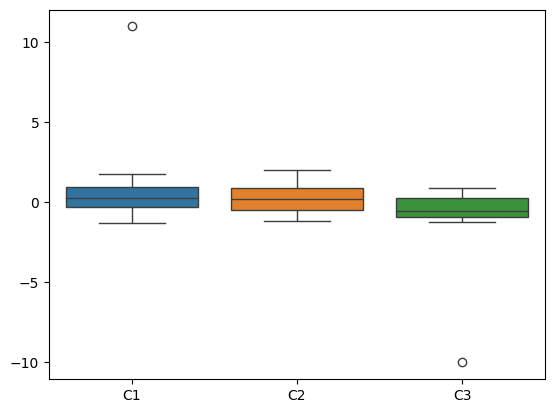

In [41]:
sns.boxplot(data=df)
plt.show()

## 데이터프레임.corr()
- 열들 사이의 상관계수(-1 ~ 1)를 계산한 표
- 1에 가까우면 강한 양의 상관관계
- -1에 가까우면 강한 음의 상관관계
- heatmap 그래프로 상관관계를 표현할 수 있다
    - annot = True : 히트맵의 각 칸에 실제 상관계수 숫자를 함께 표시해준다

In [42]:
df.corr()

,C1,C2,C3
C1,1.000000,0.533680,0.229043
C2,0.533680,1.000000,-0.013312
C3,0.229043,-0.013312,1.000000


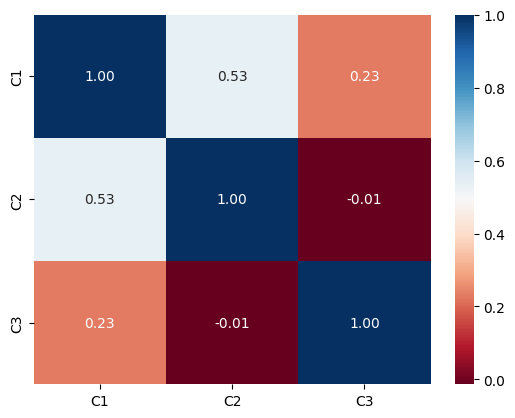

In [47]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu')
plt.show()